In [1]:
import torch
from components.datasets import load_dataset
from components.models import init_mf_params, create_anfis_model
from components.trainer import train_model
import numpy as np

# Config
config = {
    "dataset": "spiral", # options: mackey-glass, circles, spiral, moons, swiss-roll, iris, digits, cryotherapy, pima, haberman, immunotherapy, thyroid, mnist, breast-cancer-wisconsin, adult-income, bank-marketing, car-evaluation, credit-card
    "mf_type": "advanced", # options: simple, advanced
    "mf_init": "random_uniform", # options: fcm, random_uniform
    "K": 3, # number of rules (MFs per input)
    "s_mode": "alpha_beta",
    "n_epochs": 1000,
    "lr": 0.001,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seed": 42,
}

# 1) Load dataset
X_train, X_test, y_train, y_test, task_type, n_outputs = load_dataset(config["dataset"])

# 2) Initialize MF
centers_init, spreads_init = init_mf_params(
    X_train, K=config["K"], method=config["mf_init"], scale=1.0, seed=config["seed"]
)

# 3) Create model
model = create_anfis_model(
    config["mf_type"], centers_init, spreads_init, n_outputs=n_outputs, s_mode=config["s_mode"]
).to(config["device"])



/home/nazanin/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


task_type: classification
n_outputs: 1
y unique: [0 1]
epoch    1 | train_loss=0.685418 | val_loss=0.682177, acc=0.5900
epoch  100 | train_loss=0.656762 | val_loss=0.653117, acc=0.5863
epoch  200 | train_loss=0.655918 | val_loss=0.652281, acc=0.5875
epoch  300 | train_loss=0.652877 | val_loss=0.649062, acc=0.5938
epoch  400 | train_loss=0.643978 | val_loss=0.639935, acc=0.5950
epoch  500 | train_loss=0.620655 | val_loss=0.616214, acc=0.5813
epoch  600 | train_loss=0.585719 | val_loss=0.579068, acc=0.6388
epoch  700 | train_loss=0.535403 | val_loss=0.526918, acc=0.7088
epoch  800 | train_loss=0.490191 | val_loss=0.481664, acc=0.7525
epoch  900 | train_loss=0.463503 | val_loss=0.456237, acc=0.7575
epoch 1000 | train_loss=0.444964 | val_loss=0.441971, acc=0.7750

Final Results:
Mode: alpha_beta
Train: accuracy rate 0.763 (2442/3200) | error 0.237 (758)
Test: accuracy rate 0.775 (620/800) | error 0.225 (180)


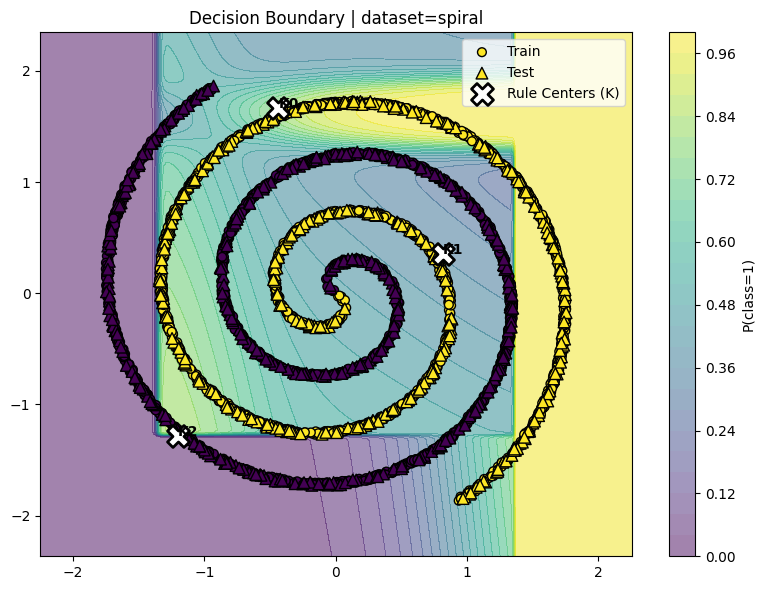

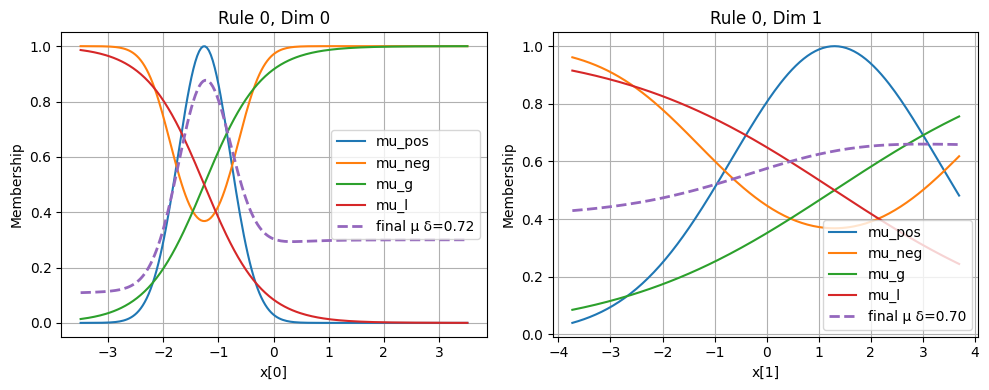

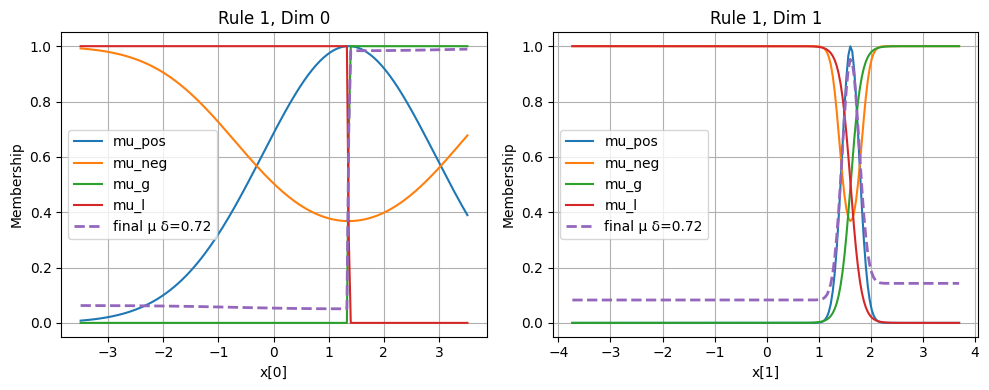

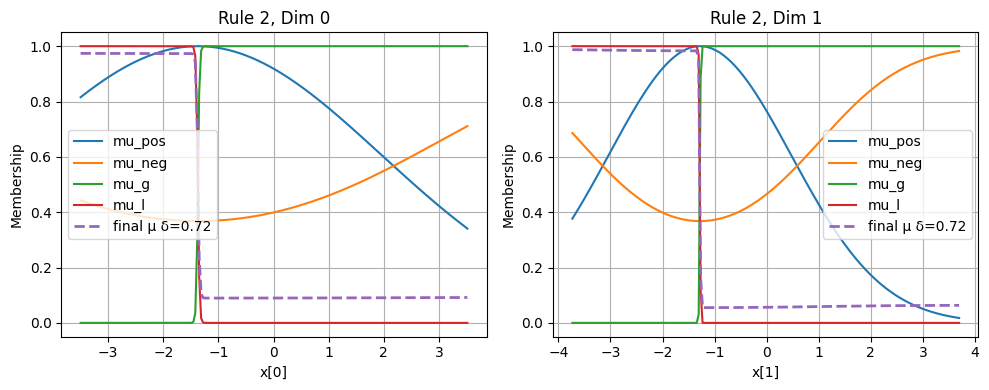

In [2]:
from components.utils import evaluate_anfis_model

print("task_type:", task_type)
print("n_outputs:", n_outputs)
print("y unique:", np.unique(y_train))


# 4) Train
model = train_model(
    model,
    X_train, y_train,
    X_test, y_test,
    task_type=task_type,
    n_outputs=n_outputs,
    n_epochs=config["n_epochs"],
    lr=config["lr"],
    device=config["device"],
)


# 5) Evaluate and plot results
evaluate_anfis_model(
    model, X_train, y_train, X_test, y_test, 
    device=config["device"], 
    s_mode_choice=config["s_mode"], 
    centers_init=centers_init,
    dataset_name=config["dataset"] 
)